In [25]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib.font_manager as font_manager

In [26]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['svg.fonttype'] = 'none'

## load layout files for multiple experiments

In [27]:
Experiment1Layout = pd.read_csv("241026_mACmChPOLR2A_ActivePolII/METADATA/241026_mACmChPOLR2A_ActivePolII.csv")
Experiment2Layout = pd.read_csv("241029_mACmChPOLR2A_ActivePolII/METADATA/241029_mACmChPOLR2A_ActivePolII.csv")
Experiment3Layout = pd.read_csv("241111_mACmChPOLR2A_ActivePolII/METADATA/241111_mACmChPOLR2A_ActivePolII.csv")

## load quantification files and assemble into dataframes

In [28]:
Experiment1_Quantification_Directory_Cycle1 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/241026_mACmChPOLR2A_ActivePolII/20241029_180349_843/QUANTIFICATION/")
Experiment1_Quantification_Directory_Cycle2 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/241026_mACmChPOLR2A_ActivePolII/20241030_173018_319/QUANTIFICATION/")

Experiment2_Quantification_Directory_Cycle1 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/241029_mACmChPOLR2A_ActivePolII/20241101_183057_182/QUANTIFICATION/")
Experiment2_Quantification_Directory_Cycle2 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/241029_mACmChPOLR2A_ActivePolII/20241104_185759_772/QUANTIFICATION/")

Experiment3_Quantification_Directory_Cycle1 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/241111_mACmChPOLR2A_ActivePolII/20241114_190600_018/QUANTIFICATION/")
Experiment3_Quantification_Directory_Cycle2 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/241111_mACmChPOLR2A_ActivePolII/20241115_164752_840/QUANTIFICATION/")

Experiment1_Cycle1_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory_Cycle1 / "*.csv"))
Experiment1_Cycle2_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory_Cycle2 / "*.csv"))

Experiment2_Cycle1_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory_Cycle1 / "*.csv"))
Experiment2_Cycle2_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory_Cycle2 / "*.csv"))

Experiment3_Cycle1_Quantification_Files = glob.glob(str(Experiment3_Quantification_Directory_Cycle1 / "*.csv"))
Experiment3_Cycle2_Quantification_Files = glob.glob(str(Experiment3_Quantification_Directory_Cycle2 / "*.csv"))

[len(i) for i in [Experiment1_Cycle1_Quantification_Files, 
                 Experiment1_Cycle2_Quantification_Files, 
                 Experiment2_Cycle1_Quantification_Files, 
                 Experiment2_Cycle2_Quantification_Files,
                 Experiment3_Cycle1_Quantification_Files,
                 Experiment3_Cycle2_Quantification_Files]]

[958, 2155, 931, 2083, 955, 2155]

In [29]:
qdfs = list()


for f in tqdm(Experiment1_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_Cycle1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment1_Cycle1_PerCell['fov'] = fovs

Intensities_Experiment1_Cycle1 = pd.DataFrame({
    "WELL" : Experiment1_Cycle1_PerCell['well'],
    "RFP_Intensity" : Experiment1_Cycle1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_Intensity" : Experiment1_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment1_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment1_Cycle1_PerCell['Nuclei_area']
})

100%|████████████████████████████████████████| 958/958 [00:03<00:00, 309.05it/s]


In [30]:
qdfs = list()


for f in tqdm(Experiment1_Cycle2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_Cycle2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_Cycle2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_Cycle2_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment1_Cycle2_PerCell['fov'] = fovs

Intensities_Experiment1_Cycle2 = pd.DataFrame({
    "WELL" : Experiment1_Cycle2_PerCell['well'],
    "Alexa647_Intensity" : Experiment1_Cycle2_PerCell['Nuclei_intensity_mean_647'],
    "NucleusArea2" : Experiment1_Cycle2_PerCell['Nuclei_area']
})

100%|██████████████████████████████████████| 2155/2155 [00:06<00:00, 333.01it/s]


In [31]:
qdfs = list()


for f in tqdm(Experiment2_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_Cycle1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment2_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment2_Cycle1_PerCell['fov'] = fovs

Intensities_Experiment2_Cycle1 = pd.DataFrame({
    "WELL" : Experiment2_Cycle1_PerCell['well'],
    "RFP_Intensity" : Experiment2_Cycle1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_Intensity" : Experiment2_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment2_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment2_Cycle1_PerCell['Nuclei_area']
})

100%|████████████████████████████████████████| 931/931 [00:03<00:00, 247.00it/s]


In [32]:
qdfs = list()


for f in tqdm(Experiment2_Cycle2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_Cycle2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_Cycle2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment2_Cycle2_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment2_Cycle2_PerCell['fov'] = fovs

Intensities_Experiment2_Cycle2 = pd.DataFrame({
    "WELL" : Experiment2_Cycle2_PerCell['well'],
    "Alexa647_Intensity" : Experiment2_Cycle2_PerCell['Nuclei_intensity_mean_647'],
    "NucleusArea2" : Experiment2_Cycle2_PerCell['Nuclei_area']
})

100%|██████████████████████████████████████| 2083/2083 [00:06<00:00, 300.63it/s]


In [33]:
qdfs = list()


for f in tqdm(Experiment3_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment3_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment3_Cycle1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment3_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment3_Cycle1_PerCell['fov'] = fovs

Intensities_Experiment3_Cycle1 = pd.DataFrame({
    "WELL" : Experiment3_Cycle1_PerCell['well'],
    "RFP_Intensity" : Experiment3_Cycle1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_Intensity" : Experiment3_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment3_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment3_Cycle1_PerCell['Nuclei_area']
})

100%|████████████████████████████████████████| 955/955 [00:02<00:00, 319.15it/s]


In [34]:
qdfs = list()


for f in tqdm(Experiment3_Cycle2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment3_Cycle2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment3_Cycle2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment3_Cycle2_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment3_Cycle2_PerCell['fov'] = fovs

Intensities_Experiment3_Cycle2 = pd.DataFrame({
    "WELL" : Experiment3_Cycle2_PerCell['well'],
    "Alexa647_Intensity" : Experiment3_Cycle2_PerCell['Nuclei_intensity_mean_647'],
    "NucleusArea2" : Experiment3_Cycle2_PerCell['Nuclei_area']
})

100%|██████████████████████████████████████| 2155/2155 [00:06<00:00, 341.70it/s]


## average by individual wells, add cell counts, and merge with layouts,

In [35]:
CountsByWell1 = Intensities_Experiment1_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment1_Cycle1 = Intensities_Experiment1_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment1Layout, how = 'left')
IntensitiesByWell_Experiment1_Cycle1 = IntensitiesByWell_Experiment1_Cycle1.merge(CountsByWell1)
IntensitiesByWell_Experiment1_Cycle2 = Intensities_Experiment1_Cycle2.groupby('WELL').mean().reset_index()

IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1_Cycle1.merge(IntensitiesByWell_Experiment1_Cycle2, how = 'left', left_on = "WELL", right_on = "WELL")
IntensitiesByWell_Experiment1['EXPERIMENT'] = '241026_mACmChPOLR2A_ActivePolII'

In [36]:
CountsByWell2 = Intensities_Experiment2_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment2_Cycle1 = Intensities_Experiment2_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment2Layout, how = 'left')
IntensitiesByWell_Experiment2_Cycle1 = IntensitiesByWell_Experiment2_Cycle1.merge(CountsByWell1)
IntensitiesByWell_Experiment2_Cycle2 = Intensities_Experiment2_Cycle2.groupby('WELL').mean().reset_index()

IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2_Cycle1.merge(IntensitiesByWell_Experiment2_Cycle2, how = 'left', left_on = "WELL", right_on = "WELL")
IntensitiesByWell_Experiment2['EXPERIMENT'] = '241029_mACmChPOLR2A_ActivePolII'

In [37]:
CountsByWell2 = Intensities_Experiment3_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment3_Cycle1 = Intensities_Experiment3_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment3Layout, how = 'left')
IntensitiesByWell_Experiment3_Cycle1 = IntensitiesByWell_Experiment3_Cycle1.merge(CountsByWell1)
IntensitiesByWell_Experiment3_Cycle2 = Intensities_Experiment3_Cycle2.groupby('WELL').mean().reset_index()

IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3_Cycle1.merge(IntensitiesByWell_Experiment3_Cycle2, how = 'left', left_on = "WELL", right_on = "WELL")
IntensitiesByWell_Experiment3['EXPERIMENT'] = '241111_mACmChPOLR2A_ActivePolII'

## save per well summaries of each experiment

In [39]:
IntensitiesByWell_Experiment1.head()

,WELL,RFP_Intensity,GFP_Intensity,DAPI_Intensity,NucleusArea,CELL,EU,DRUG,DRUG TIME MINUTES,PRIMARY,SECONDARY,TotalNumberCells,Alexa647_Intensity,NucleusArea2,EXPERIMENT
0,C03,176.593696,198.186006,459.454157,1662.368875,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,1857,407.383421,1611.653717,241026_mACmChPOLR2A_ActivePolII
1,C04,172.371342,196.033521,399.990981,1638.156010,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,2346,416.834453,1585.146507,241026_mACmChPOLR2A_ActivePolII
2,C05,205.619134,195.175253,480.696064,1652.004288,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,2332,388.699571,1611.924059,241026_mACmChPOLR2A_ActivePolII
3,C06,178.665062,193.735350,487.173855,1733.538636,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,1760,369.427604,1621.400627,241026_mACmChPOLR2A_ActivePolII
4,C07,177.026921,193.867747,449.760708,1650.125000,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,2032,379.570174,1598.757861,241026_mACmChPOLR2A_ActivePolII


In [40]:
IntensitiesByWell_Experiment2.head()

,WELL,RFP_Intensity,GFP_Intensity,DAPI_Intensity,NucleusArea,CELL,EU,DRUG,DRUG TIME MINUTES,PRIMARY,SECONDARY,TotalNumberCells,Alexa647_Intensity,NucleusArea2,EXPERIMENT
0,C03,180.264208,239.470411,238.841866,1742.317026,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,1857,960.970711,1719.763836,241029_mACmChPOLR2A_ActivePolII
1,C04,182.161683,240.046047,246.876854,1674.366129,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,2346,876.333913,1673.139755,241029_mACmChPOLR2A_ActivePolII
2,C05,180.973328,239.662826,243.549051,1678.131729,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,2332,883.956984,1646.175796,241029_mACmChPOLR2A_ActivePolII
3,C06,181.092249,239.980610,246.095176,1715.389974,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,1760,922.067322,1636.902701,241029_mACmChPOLR2A_ActivePolII
4,C07,180.945170,238.184748,242.690967,1665.156949,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,2032,885.173281,1686.019629,241029_mACmChPOLR2A_ActivePolII


In [41]:
IntensitiesByWell_Experiment3.head()

,WELL,RFP_Intensity,GFP_Intensity,DAPI_Intensity,NucleusArea,CELL,EU,DRUG,DRUG TIME MINUTES,PRIMARY,SECONDARY,TotalNumberCells,Alexa647_Intensity,NucleusArea2,EXPERIMENT
0,C03,218.589964,274.529801,336.640127,1729.858871,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,1857,913.338094,1703.942456,241111_mACmChPOLR2A_ActivePolII
1,C04,218.115524,272.585997,324.059853,1715.613062,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,2346,908.963737,1638.313205,241111_mACmChPOLR2A_ActivePolII
2,C05,217.141684,272.113034,318.761401,1717.180451,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,2332,893.978279,1627.093889,241111_mACmChPOLR2A_ActivePolII
3,C06,217.026863,269.092669,351.740106,1717.787879,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,1760,901.513801,1665.590909,241111_mACmChPOLR2A_ActivePolII
4,C07,217.433731,270.830668,347.946383,1669.873931,HCT116 OsTIRF74G,No addition,No addition,No addition,Total Pol II F12,Goat anti-mouse Alexa647,2032,894.849628,1629.733876,241111_mACmChPOLR2A_ActivePolII


In [42]:
IntensitiesByWell_Experiment1.to_csv('241026_mACmChPOLR2A_ActivePolII/241026_mACmChPOLR2A_ActivePolII_well_means.csv')

In [43]:
IntensitiesByWell_Experiment2.to_csv('241029_mACmChPOLR2A_ActivePolII/241029_mACmChPOLR2A_ActivePolII_well_means.csv')

In [44]:
IntensitiesByWell_Experiment3.to_csv('241111_mACmChPOLR2A_ActivePolII/241111_mACmChPOLR2A_ActivePolII_well_means.csv')

## examine raw data per experiment

In [45]:
IntensitiesByWell_Experiment1.CELL.unique()

array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5',
       'HCT116 mChPOLR2A Clone 2',
       'HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1'], dtype=object)

In [46]:
IntensitiesByWell_Experiment1.DRUG.unique()

array(['No addition', '10 µM 5PhIAA', 'Vehicle'], dtype=object)

In [47]:
cell_relabel = dict(zip(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5','HCT116 mChPOLR2A Clone 2','HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1'],
                        ['OsTIRF74G', 'mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A']))

### experiment 1

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/3773484762.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment1_Baseline['CELL'].map(cell_relabel)


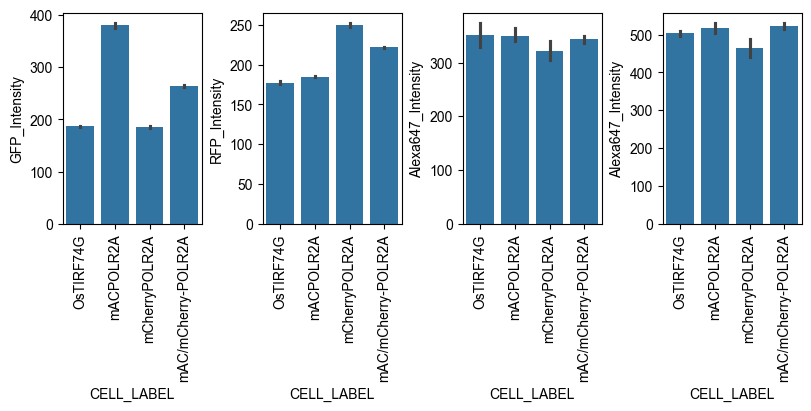

In [48]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment1_Baseline = IntensitiesByWell_Experiment1.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment1_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment1_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment1_Baseline,
            x = 'CELL_LABEL', order = ['OsTIRF74G', 'mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'],
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment1_Baseline,
            x = 'CELL_LABEL', order = ['OsTIRF74G', 'mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'],
            y = 'RFP_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment1_Baseline.query('PRIMARY == "Total Pol II F12"'),
            x = 'CELL_LABEL', order = ['OsTIRF74G', 'mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'],
            y = 'Alexa647_Intensity',
            ax = a[2])

sns.barplot(IntensitiesByWell_Experiment1_Baseline.query('PRIMARY == "pSer2 3E10"'),
            x = 'CELL_LABEL', order = ['OsTIRF74G', 'mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'],
            y = 'Alexa647_Intensity',
            ax = a[3])

for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/1486505125.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_Exclude_No_Addition['TIME_MINUTES'] = IntensitiesByWell_Experiment1_Exclude_No_Addition['DRUG TIME MINUTES'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/1486505125.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_Exclude_No_Addition['CELL_LABEL'] = IntensitiesByWell_Experiment1_Exclude

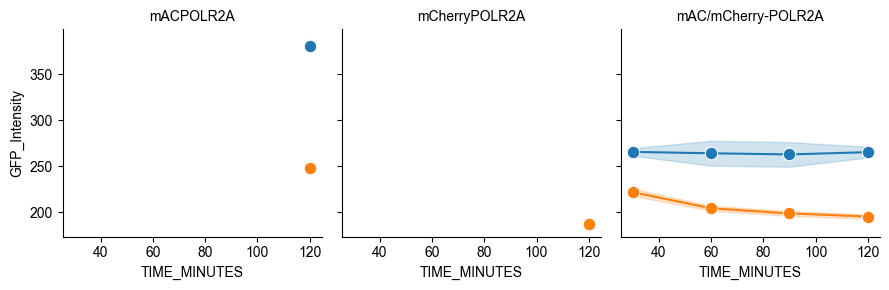

In [49]:
IntensitiesByWell_Experiment1_Exclude_No_Addition = IntensitiesByWell_Experiment1.query('DRUG != "No addition"')
IntensitiesByWell_Experiment1_Exclude_No_Addition['TIME_MINUTES'] = IntensitiesByWell_Experiment1_Exclude_No_Addition['DRUG TIME MINUTES'].astype('int')


IntensitiesByWell_Experiment1_Exclude_No_Addition['CELL_LABEL'] = IntensitiesByWell_Experiment1_Exclude_No_Addition['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment1_Exclude_No_Addition,
                  col = 'CELL_LABEL',
                  col_order =  ['mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'])

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'GFP_Intensity',
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

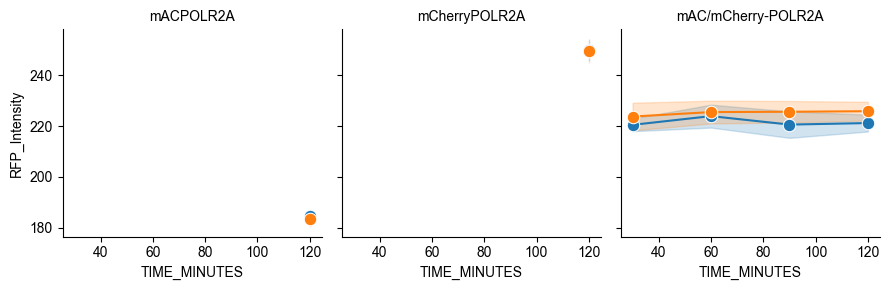

In [50]:
g = sns.FacetGrid(IntensitiesByWell_Experiment1_Exclude_No_Addition,
                  col = 'CELL_LABEL',
                  col_order =  ['mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'])

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'RFP_Intensity',
                hue = 'DRUG',  hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

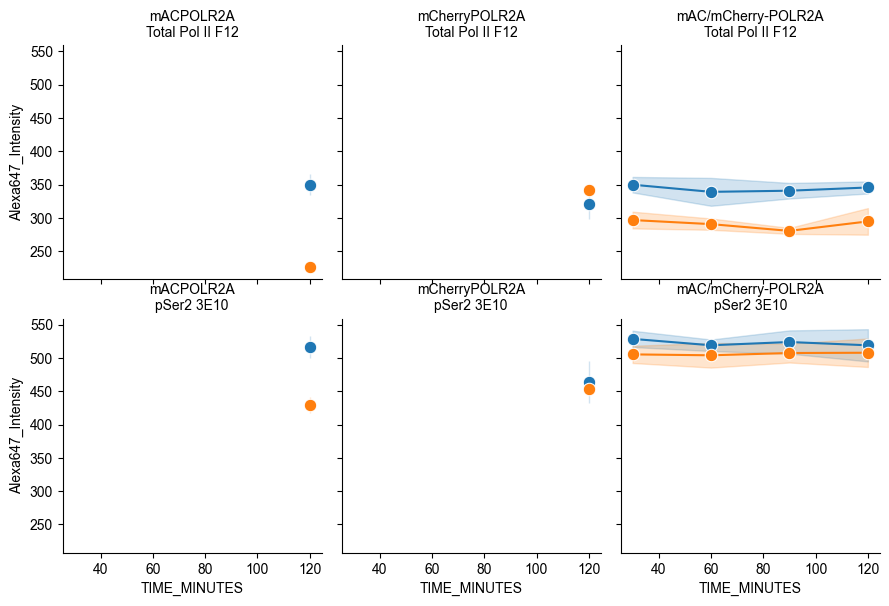

In [51]:
g = sns.FacetGrid(IntensitiesByWell_Experiment1_Exclude_No_Addition,
                  col = 'CELL_LABEL',
                  col_order =  ['mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'],
                  row = 'PRIMARY', row_order = ["Total Pol II F12", "pSer2 3E10"])

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'Alexa647_Intensity',
                hue = 'DRUG',  hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}\n{row_name}")

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/485388179.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_EU['CELL_LABEL'] = IntensitiesByWell_Experiment1_EU['CELL'].map(cell_relabel)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/485388179.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_EU['TIME_MINUTES'] = IntensitiesByWell_Experiment1_EU['DRUG TIME MINUTES'].astype('int')


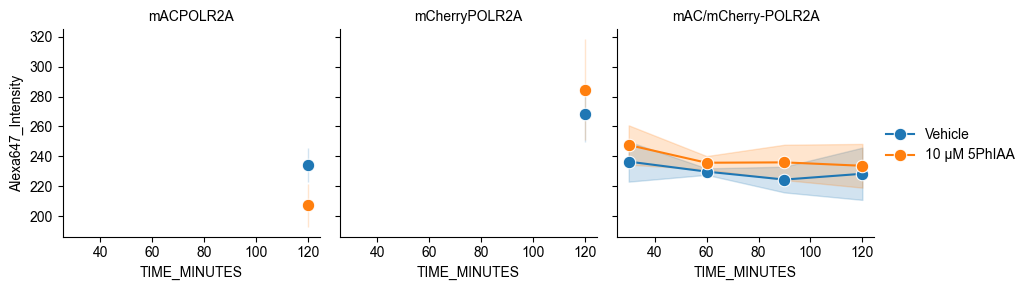

In [52]:
IntensitiesByWell_Experiment1_EU = IntensitiesByWell_Experiment1.query('EU == "EU 1 mM, 30 mins" & DRUG != "No addition"')
IntensitiesByWell_Experiment1_EU['CELL_LABEL'] = IntensitiesByWell_Experiment1_EU['CELL'].map(cell_relabel)
IntensitiesByWell_Experiment1_EU['TIME_MINUTES'] = IntensitiesByWell_Experiment1_EU['DRUG TIME MINUTES'].astype('int')

g = sns.FacetGrid(IntensitiesByWell_Experiment1_EU,
                  col = 'CELL_LABEL',
                  col_order =  ['mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'])

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'Alexa647_Intensity',
                hue = 'DRUG',  hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")
g.add_legend()

### experiment 2

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/1839796053.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment2_Baseline['CELL'].map(cell_relabel)


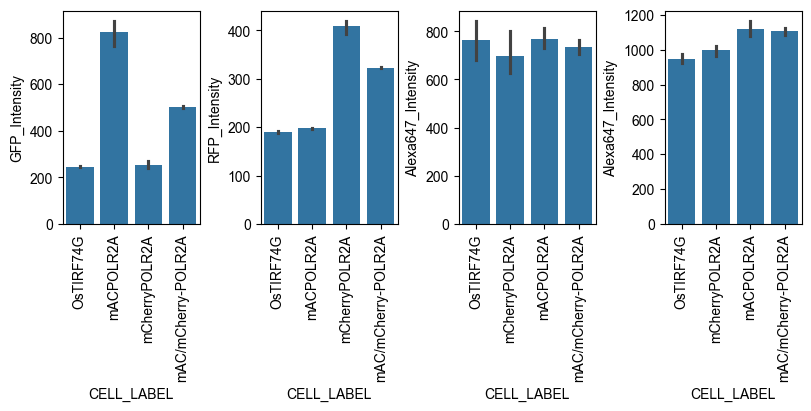

In [53]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment2_Baseline = IntensitiesByWell_Experiment2.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment2_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment2_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment2_Baseline,
            x = 'CELL_LABEL',
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment2_Baseline,
            x = 'CELL_LABEL',
            y = 'RFP_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment2_Baseline.query('PRIMARY == "Total Pol II F12"'),
            x = 'CELL_LABEL',
            y = 'Alexa647_Intensity',
            ax = a[2])

sns.barplot(IntensitiesByWell_Experiment2_Baseline.query('PRIMARY == "pSer2 3E10"'),
            x = 'CELL_LABEL',
            y = 'Alexa647_Intensity',
            ax = a[3])

for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)
    

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/1170954120.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_Exclude_No_Addition['TIME_MINUTES'] = IntensitiesByWell_Experiment2_Exclude_No_Addition['DRUG TIME MINUTES'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/1170954120.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_Exclude_No_Addition['CELL_LABEL'] = IntensitiesByWell_Experiment2_Exclude

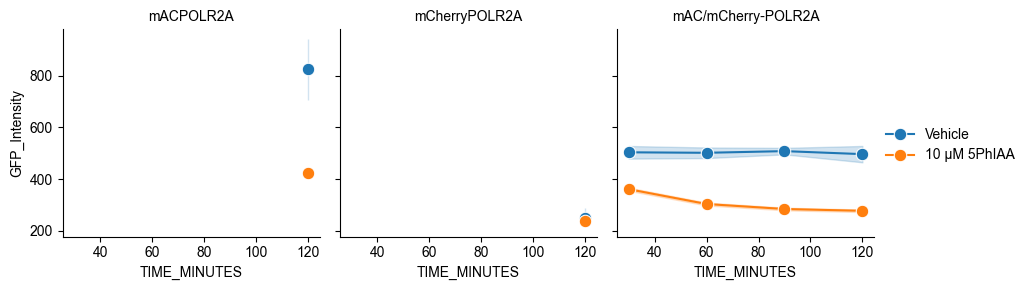

In [54]:
IntensitiesByWell_Experiment2_Exclude_No_Addition = IntensitiesByWell_Experiment2.query('DRUG != "No addition"')
IntensitiesByWell_Experiment2_Exclude_No_Addition['TIME_MINUTES'] = IntensitiesByWell_Experiment2_Exclude_No_Addition['DRUG TIME MINUTES'].astype('int')


IntensitiesByWell_Experiment2_Exclude_No_Addition['CELL_LABEL'] = IntensitiesByWell_Experiment2_Exclude_No_Addition['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment2_Exclude_No_Addition,
                  col = 'CELL_LABEL',
                  col_order =  ['mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'])

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'GFP_Intensity',
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")
g.add_legend()

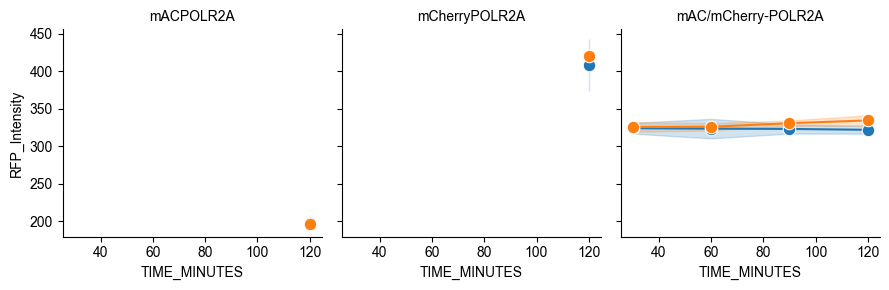

In [55]:
g = sns.FacetGrid(IntensitiesByWell_Experiment2_Exclude_No_Addition,
                  col = 'CELL_LABEL',
                  col_order =  ['mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'])

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'RFP_Intensity',
                hue = 'DRUG',  hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

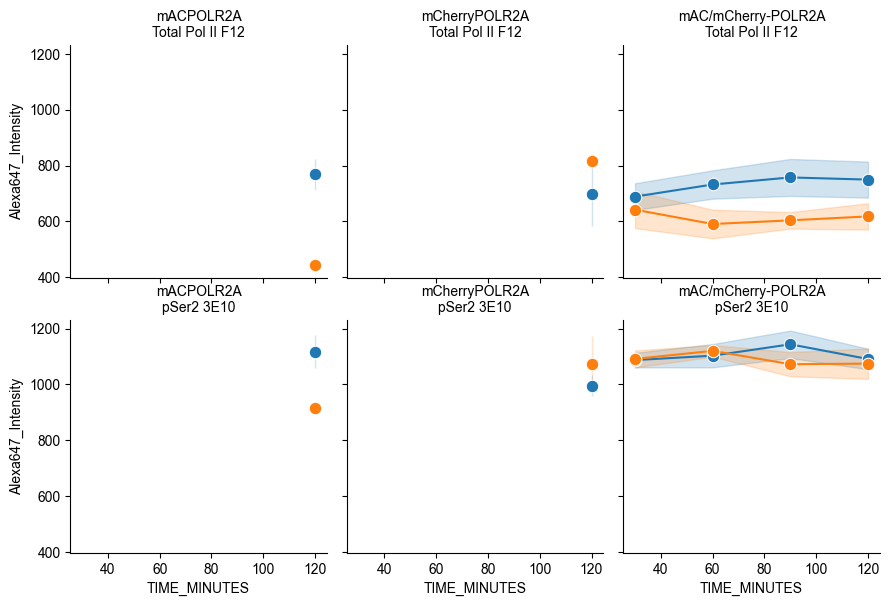

In [56]:
g = sns.FacetGrid(IntensitiesByWell_Experiment2_Exclude_No_Addition,
                  col = 'CELL_LABEL',
                  col_order =  ['mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'],
                  row = 'PRIMARY', row_order = ["Total Pol II F12", "pSer2 3E10"])

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'Alexa647_Intensity',
                hue = 'DRUG',  hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}\n{row_name}")

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/108973058.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_EU['CELL_LABEL'] = IntensitiesByWell_Experiment2_EU['CELL'].map(cell_relabel)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/108973058.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_EU['TIME_MINUTES'] = IntensitiesByWell_Experiment2_EU['DRUG TIME MINUTES'].astype('int')


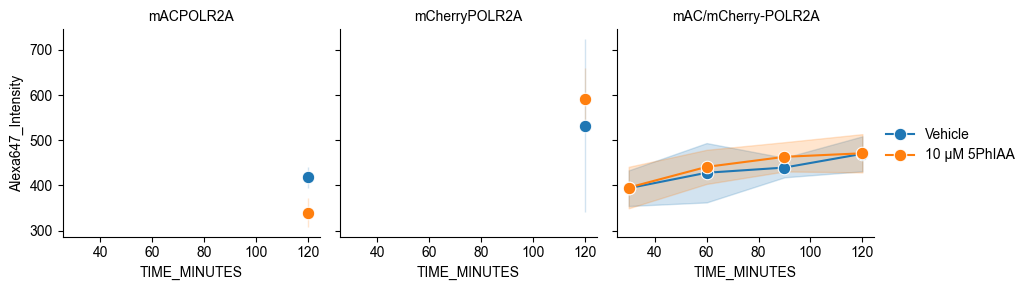

In [57]:
IntensitiesByWell_Experiment2_EU = IntensitiesByWell_Experiment2.query('EU == "EU 1 mM, 30 mins" & DRUG != "No addition"')
IntensitiesByWell_Experiment2_EU['CELL_LABEL'] = IntensitiesByWell_Experiment2_EU['CELL'].map(cell_relabel)
IntensitiesByWell_Experiment2_EU['TIME_MINUTES'] = IntensitiesByWell_Experiment2_EU['DRUG TIME MINUTES'].astype('int')

g = sns.FacetGrid(IntensitiesByWell_Experiment2_EU,
                  col = 'CELL_LABEL',
                  col_order =  ['mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'])

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'Alexa647_Intensity',
                hue = 'DRUG',  hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.add_legend()
g.set_titles(template="{col_name}")

### experiment 3

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/2378267435.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment3_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment3_Baseline['CELL'].map(cell_relabel)


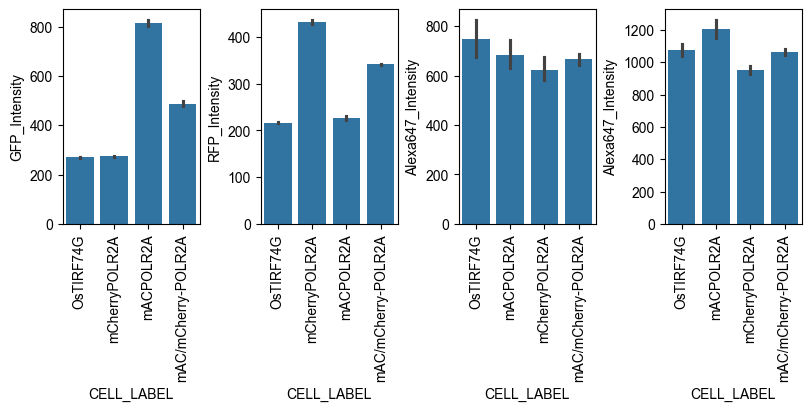

In [58]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment3_Baseline = IntensitiesByWell_Experiment3.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment3_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment3_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment3_Baseline,
            x = 'CELL_LABEL',
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment3_Baseline,
            x = 'CELL_LABEL',
            y = 'RFP_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment3_Baseline.query('PRIMARY == "Total Pol II F12"'),
            x = 'CELL_LABEL',
            y = 'Alexa647_Intensity',
            ax = a[2])

sns.barplot(IntensitiesByWell_Experiment3_Baseline.query('PRIMARY == "pSer2 3E10"'),
            x = 'CELL_LABEL',
            y = 'Alexa647_Intensity',
            ax = a[3])

for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/960321387.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment3_Exclude_No_Addition['TIME_MINUTES'] = IntensitiesByWell_Experiment3_Exclude_No_Addition['DRUG TIME MINUTES'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/960321387.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment3_Exclude_No_Addition['CELL_LABEL'] = IntensitiesByWell_Experiment3_Exclude_N

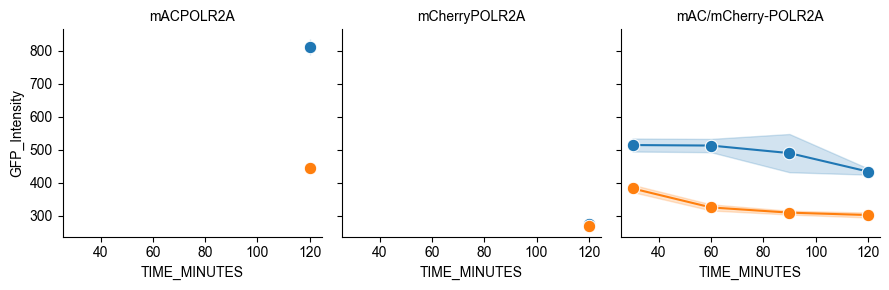

In [59]:
IntensitiesByWell_Experiment3_Exclude_No_Addition = IntensitiesByWell_Experiment3.query('DRUG != "No addition"')
IntensitiesByWell_Experiment3_Exclude_No_Addition['TIME_MINUTES'] = IntensitiesByWell_Experiment3_Exclude_No_Addition['DRUG TIME MINUTES'].astype('int')
IntensitiesByWell_Experiment3_Exclude_No_Addition['CELL_LABEL'] = IntensitiesByWell_Experiment3_Exclude_No_Addition['CELL'].map(cell_relabel)

g = sns.FacetGrid(IntensitiesByWell_Experiment3_Exclude_No_Addition,
                  col = 'CELL_LABEL',
                  col_order =  ['mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'])

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'GFP_Intensity',
                hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

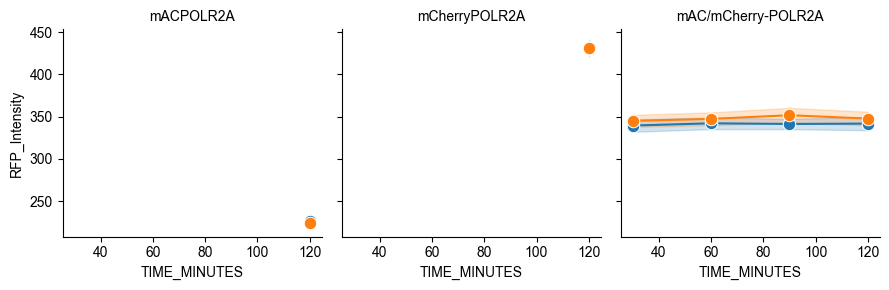

In [60]:
g = sns.FacetGrid(IntensitiesByWell_Experiment3_Exclude_No_Addition,
                  col = 'CELL_LABEL',
                  col_order =  ['mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'])

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'RFP_Intensity',
                hue = 'DRUG',  hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

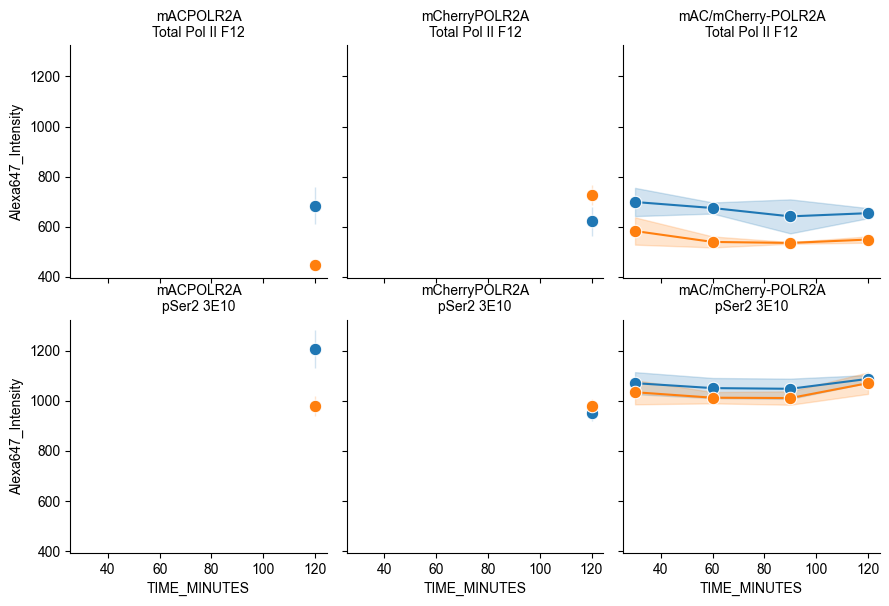

In [61]:
g = sns.FacetGrid(IntensitiesByWell_Experiment3_Exclude_No_Addition,
                  col = 'CELL_LABEL',
                  col_order =  ['mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'],
                  row = 'PRIMARY', row_order = ["Total Pol II F12", "pSer2 3E10"])

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'Alexa647_Intensity',
                hue = 'DRUG',  hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}\n{row_name}")

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/602690009.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment3_EU['CELL_LABEL'] = IntensitiesByWell_Experiment3_EU['CELL'].map(cell_relabel)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/602690009.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment3_EU['TIME_MINUTES'] = IntensitiesByWell_Experiment3_EU['DRUG TIME MINUTES'].astype('int')


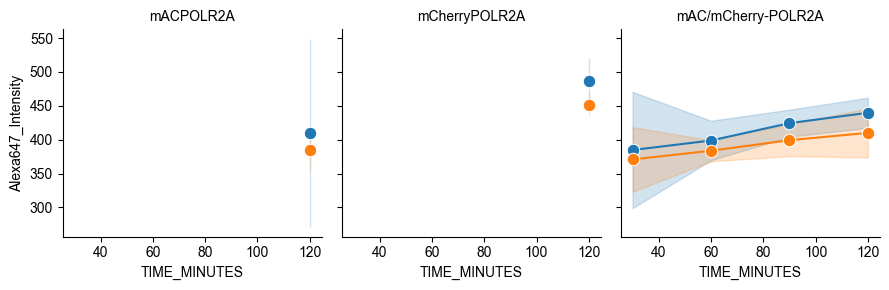

In [62]:
IntensitiesByWell_Experiment3_EU = IntensitiesByWell_Experiment3.query('EU == "EU 1 mM, 30 mins"')
IntensitiesByWell_Experiment3_EU['CELL_LABEL'] = IntensitiesByWell_Experiment3_EU['CELL'].map(cell_relabel)
IntensitiesByWell_Experiment3_EU['TIME_MINUTES'] = IntensitiesByWell_Experiment3_EU['DRUG TIME MINUTES'].astype('int')

g = sns.FacetGrid(IntensitiesByWell_Experiment3_EU,
                  col = 'CELL_LABEL',
                  col_order =  ['mACPOLR2A', 'mCherryPOLR2A', 'mAC/mCherry-POLR2A'])

g.map_dataframe(sns.lineplot,
                x = 'TIME_MINUTES',
                y = 'Alexa647_Intensity',
                hue = 'DRUG',  hue_order = ['Vehicle', '10 µM 5PhIAA'],
                marker = 'o', markersize = 9,
                errorbar = 'sd')

g.set_titles(template="{col_name}")

## background subtract and normalise within experiments

### RFP and GFP

In [63]:
E1_GFP_Zero = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E2_GFP_Zero = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E3_GFP_Zero = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['GFP_Intensity'] - E1_GFP_Zero
IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['GFP_Intensity'] - E2_GFP_Zero
IntensitiesByWell_Experiment3['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment3['GFP_Intensity'] - E3_GFP_Zero

E1_GFP_NV = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()
E2_GFP_NV = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()
E3_GFP_NV = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A-delHyg Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_FC'] = IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] / E1_GFP_NV
IntensitiesByWell_Experiment2['GFP_Intensity_FC'] = IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] / E2_GFP_NV
IntensitiesByWell_Experiment3['GFP_Intensity_FC'] = IntensitiesByWell_Experiment3['GFP_Intensity_BGS'] / E3_GFP_NV

In [64]:
E1_RFP_Zero = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').RFP_Intensity.mean()
E2_RFP_Zero = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').RFP_Intensity.mean()
E3_RFP_Zero = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G"').RFP_Intensity.mean()

IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['RFP_Intensity'] - E1_RFP_Zero
IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['RFP_Intensity'] - E2_RFP_Zero
IntensitiesByWell_Experiment3['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment3['RFP_Intensity'] - E3_RFP_Zero

E1_RFP_NV = IntensitiesByWell_Experiment1.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG == "Vehicle"').RFP_Intensity_BGS.mean()
E2_RFP_NV = IntensitiesByWell_Experiment2.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG == "Vehicle"').RFP_Intensity_BGS.mean()
E3_RFP_NV = IntensitiesByWell_Experiment3.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG == "Vehicle"').RFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['RFP_Intensity_FC'] = IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] / E1_RFP_NV
IntensitiesByWell_Experiment2['RFP_Intensity_FC'] = IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] / E2_RFP_NV
IntensitiesByWell_Experiment3['RFP_Intensity_FC'] = IntensitiesByWell_Experiment3['RFP_Intensity_BGS'] / E3_RFP_NV

In [65]:
IntensitiesByWell = pd.concat([IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2, IntensitiesByWell_Experiment3])

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/579450394.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_Plot['TIME_MINUTES'] = IntensitiesByWell_Experiment1_Plot['DRUG TIME MINUTES'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/579450394.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_Plot['TIME_MINUTES'] = IntensitiesByWell_Experiment2_Plot['DRUG TIME MINUTES'].astype('int')
/var/folders

Text(0.5, 1.0, '241111_mACmChPOLR2A_ActivePolII\nRFP intensity')

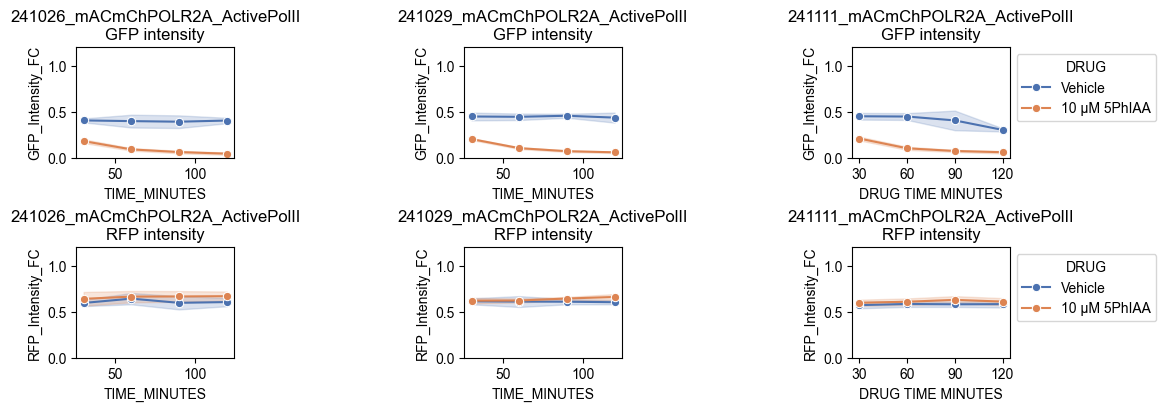

In [66]:
f, a = plt.subplots(ncols = 3, nrows = 2, figsize = (12,4), layout = 'constrained')

IntensitiesByWell_Experiment1_Plot =IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
IntensitiesByWell_Experiment1_Plot['TIME_MINUTES'] = IntensitiesByWell_Experiment1_Plot['DRUG TIME MINUTES'].astype('int')

IntensitiesByWell_Experiment2_Plot = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
IntensitiesByWell_Experiment2_Plot['TIME_MINUTES'] = IntensitiesByWell_Experiment2_Plot['DRUG TIME MINUTES'].astype('int')

IntensitiesByWell_Experiment3_Plot = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
IntensitiesByWell_Experiment3_Plot['TIME_MINUTES'] = IntensitiesByWell_Experiment3_Plot['DRUG TIME MINUTES'].astype('int')

h = sns.lineplot(
    IntensitiesByWell_Experiment1_Plot,
    x = 'TIME_MINUTES',
    y = 'GFP_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[0,0],
    legend = False
)

h = sns.lineplot(
    IntensitiesByWell_Experiment2_Plot,
    x = 'TIME_MINUTES',
    y = 'GFP_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[0,1],
    legend = False
)


h = sns.lineplot(
    IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
    x = 'DRUG TIME MINUTES',
    y = 'GFP_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[0,2]
)


sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.lineplot(
    IntensitiesByWell_Experiment1_Plot,
    x = 'TIME_MINUTES',
    y = 'RFP_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[1,0],
    legend = False
)

h = sns.lineplot(
    IntensitiesByWell_Experiment2_Plot,
    x = 'TIME_MINUTES',
    y = 'RFP_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[1,1],
    legend = False
)


h = sns.lineplot(
    IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
    x = 'DRUG TIME MINUTES',
    y = 'RFP_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[1,2]
)

sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

for i in range(2):
    for j in range(3):
        a[i,j].set_ylim(0,1.2)
        a[i,j].set_box_aspect(0.7)

a[0,0].set_title('241026_mACmChPOLR2A_ActivePolII\nGFP intensity')
a[0,1].set_title('241029_mACmChPOLR2A_ActivePolII\nGFP intensity')
a[0,2].set_title('241111_mACmChPOLR2A_ActivePolII\nGFP intensity')

a[1,0].set_title('241026_mACmChPOLR2A_ActivePolII\nRFP intensity')
a[1,1].set_title('241029_mACmChPOLR2A_ActivePolII\nRFP intensity')
a[1,2].set_title('241111_mACmChPOLR2A_ActivePolII\nRFP intensity')


### immunofluorescence

In [67]:
E1_Mouse_Zero = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa647"').Alexa647_Intensity.mean()
E2_Mouse_Zero = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa647"').Alexa647_Intensity.mean()
E3_Mouse_Zero = IntensitiesByWell_Experiment3.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa647"').Alexa647_Intensity.mean()

E1_Rat_Zero = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa647"').Alexa647_Intensity.mean()
E2_Rat_Zero = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa647"').Alexa647_Intensity.mean()
E3_Rat_Zero = IntensitiesByWell_Experiment3.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa647"').Alexa647_Intensity.mean()


Total_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('PRIMARY == "Total Pol II F12"')
Total_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('PRIMARY == "Total Pol II F12"')
Total_IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.query('PRIMARY == "Total Pol II F12"')

Total_IntensitiesByWell_Experiment1['Alexa647_Intensity_BGS'] = Total_IntensitiesByWell_Experiment1['Alexa647_Intensity'] - E1_Mouse_Zero
Total_IntensitiesByWell_Experiment2['Alexa647_Intensity_BGS'] = Total_IntensitiesByWell_Experiment2['Alexa647_Intensity'] - E2_Mouse_Zero
Total_IntensitiesByWell_Experiment3['Alexa647_Intensity_BGS'] = Total_IntensitiesByWell_Experiment3['Alexa647_Intensity'] - E3_Mouse_Zero

E1_Total_NV = Total_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"').Alexa647_Intensity_BGS.mean()
E2_Total_NV = Total_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"').Alexa647_Intensity_BGS.mean()
E3_Total_NV = Total_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"').Alexa647_Intensity_BGS.mean()

Total_IntensitiesByWell_Experiment1['Alexa647_Intensity_FC'] = Total_IntensitiesByWell_Experiment1['Alexa647_Intensity_BGS'] / E1_Total_NV
Total_IntensitiesByWell_Experiment2['Alexa647_Intensity_FC'] = Total_IntensitiesByWell_Experiment2['Alexa647_Intensity_BGS'] / E2_Total_NV
Total_IntensitiesByWell_Experiment3['Alexa647_Intensity_FC'] = Total_IntensitiesByWell_Experiment3['Alexa647_Intensity_BGS'] / E3_Total_NV


pSer2_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('PRIMARY == "pSer2 3E10"')
pSer2_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('PRIMARY == "pSer2 3E10"')
pSer2_IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.query('PRIMARY == "pSer2 3E10"')

pSer2_IntensitiesByWell_Experiment1['Alexa647_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment1['Alexa647_Intensity'] - E1_Rat_Zero
pSer2_IntensitiesByWell_Experiment2['Alexa647_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment2['Alexa647_Intensity'] - E2_Rat_Zero
pSer2_IntensitiesByWell_Experiment3['Alexa647_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment3['Alexa647_Intensity'] - E3_Rat_Zero

E1_pSer2_NV = pSer2_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"').Alexa647_Intensity_BGS.mean()
E2_pSer2_NV = pSer2_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"').Alexa647_Intensity_BGS.mean()
E3_pSer2_NV = pSer2_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"').Alexa647_Intensity_BGS.mean()

pSer2_IntensitiesByWell_Experiment1['Alexa647_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment1['Alexa647_Intensity_BGS'] / E1_pSer2_NV
pSer2_IntensitiesByWell_Experiment2['Alexa647_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment2['Alexa647_Intensity_BGS'] / E2_pSer2_NV
pSer2_IntensitiesByWell_Experiment3['Alexa647_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment3['Alexa647_Intensity_BGS'] / E3_pSer2_NV

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/2301308616.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment1['Alexa647_Intensity_BGS'] = Total_IntensitiesByWell_Experiment1['Alexa647_Intensity'] - E1_Mouse_Zero
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/2301308616.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment2['Alexa647_Intensity_BGS'] = Total_IntensitiesByWell_Experiment2['Alexa647_Intens

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/363090029.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment1_Plot['TIME_MINUTES'] = Total_IntensitiesByWell_Experiment1_Plot['DRUG TIME MINUTES'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/363090029.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment2_Plot['TIME_MINUTES'] = Total_IntensitiesByWell_Experiment2_Plot['DRUG TIME MINUTES'].as

Text(0.5, 1.0, '241111_mACmChPOLR2A_ActivePolII\npSer2 Pol II intensity (3E10)')

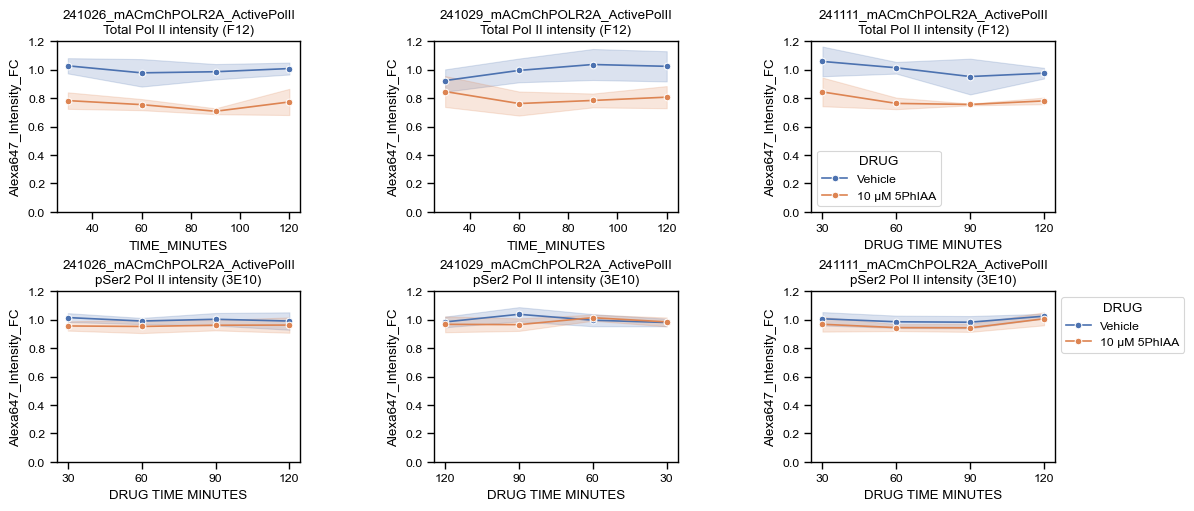

In [68]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, nrows = 2, figsize = (12,5), layout = 'constrained')

Total_IntensitiesByWell_Experiment1_Plot = Total_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
Total_IntensitiesByWell_Experiment1_Plot['TIME_MINUTES'] = Total_IntensitiesByWell_Experiment1_Plot['DRUG TIME MINUTES'].astype('int')

Total_IntensitiesByWell_Experiment2_Plot = Total_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
Total_IntensitiesByWell_Experiment2_Plot['TIME_MINUTES'] = Total_IntensitiesByWell_Experiment2_Plot['DRUG TIME MINUTES'].astype('int')

Total_IntensitiesByWell_Experiment3_Plot = Total_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
Total_IntensitiesByWell_Experiment3_Plot['TIME_MINUTES'] = Total_IntensitiesByWell_Experiment3_Plot['DRUG TIME MINUTES'].astype('int')

h = sns.lineplot(
    Total_IntensitiesByWell_Experiment1_Plot,
    x = 'TIME_MINUTES',
    y = 'Alexa647_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[0,0],
    legend = False
)

h = sns.lineplot(
    Total_IntensitiesByWell_Experiment2_Plot,
    x = 'TIME_MINUTES',
    y = 'Alexa647_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[0,1],
    legend = False
)


h = sns.lineplot(
    Total_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
    x = 'DRUG TIME MINUTES',
    y = 'Alexa647_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[0,2]
)

pSer2_IntensitiesByWell_Experiment1_Plot = pSer2_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
pSer2_IntensitiesByWell_Experiment1_Plot['TIME_MINUTES'] = pSer2_IntensitiesByWell_Experiment1_Plot['DRUG TIME MINUTES'].astype('int')

pSer2_IntensitiesByWell_Experiment2_Plot = pSer2_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
pSer2_IntensitiesByWell_Experiment2_Plot['TIME_MINUTES'] = pSer2_IntensitiesByWell_Experiment2_Plot['DRUG TIME MINUTES'].astype('int')

pSer2_IntensitiesByWell_Experiment3_Plot = pSer2_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
pSer2_IntensitiesByWell_Experiment3_Plot['TIME_MINUTES'] = pSer2_IntensitiesByWell_Experiment3_Plot['DRUG TIME MINUTES'].astype('int')

h = sns.lineplot(
    pSer2_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
    x = 'DRUG TIME MINUTES',
    y = 'Alexa647_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[1,0],
    legend = False
)

h = sns.lineplot(
    pSer2_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
    x = 'DRUG TIME MINUTES',
    y = 'Alexa647_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[1,1],
    legend = False
)


h = sns.lineplot(
    pSer2_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"'),
    x = 'DRUG TIME MINUTES',
    y = 'Alexa647_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[1,2]
)

sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

#sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

for i in range(2):
    for j in range(3):
        a[i,j].set_ylim(0,1.2)
        a[i,j].set_box_aspect(0.7)

a[0,0].set_title('241026_mACmChPOLR2A_ActivePolII\nTotal Pol II intensity (F12)')
a[0,1].set_title('241029_mACmChPOLR2A_ActivePolII\nTotal Pol II intensity (F12)')
a[0,2].set_title('241111_mACmChPOLR2A_ActivePolII\nTotal Pol II intensity (F12)')

a[1,0].set_title('241026_mACmChPOLR2A_ActivePolII\npSer2 Pol II intensity (3E10)')
a[1,1].set_title('241029_mACmChPOLR2A_ActivePolII\npSer2 Pol II intensity (3E10)')
a[1,2].set_title('241111_mACmChPOLR2A_ActivePolII\npSer2 Pol II intensity (3E10)')


In [69]:
Total_IntensitiesByWell = pd.concat([Total_IntensitiesByWell_Experiment1, Total_IntensitiesByWell_Experiment2, Total_IntensitiesByWell_Experiment3])
pSer2_IntensitiesByWell = pd.concat([pSer2_IntensitiesByWell_Experiment1, pSer2_IntensitiesByWell_Experiment2, pSer2_IntensitiesByWell_Experiment3])

### EU

In [70]:
E1_EU_Zero = IntensitiesByWell_Experiment1.query('SECONDARY == "No secondary" & EU == "No addition"').Alexa647_Intensity.mean()
E2_EU_Zero = IntensitiesByWell_Experiment2.query('SECONDARY == "No secondary" & EU == "No addition"').Alexa647_Intensity.mean()
E3_EU_Zero = IntensitiesByWell_Experiment3.query('SECONDARY == "No secondary" & EU == "No addition"').Alexa647_Intensity.mean()

EU_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('EU == "EU 1 mM, 30 mins"')
EU_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('EU == "EU 1 mM, 30 mins"')
EU_IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.query('EU == "EU 1 mM, 30 mins"')

EU_IntensitiesByWell_Experiment1['Alexa647_Intensity_BGS'] = (EU_IntensitiesByWell_Experiment1['Alexa647_Intensity'] - E1_EU_Zero)
EU_IntensitiesByWell_Experiment2['Alexa647_Intensity_BGS'] = (EU_IntensitiesByWell_Experiment2['Alexa647_Intensity'] - E2_EU_Zero)
EU_IntensitiesByWell_Experiment3['Alexa647_Intensity_BGS'] = (EU_IntensitiesByWell_Experiment3['Alexa647_Intensity'] - E3_EU_Zero)

E1_Total_NV = EU_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"').Alexa647_Intensity_BGS.mean()
E2_Total_NV = EU_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"').Alexa647_Intensity_BGS.mean()
E3_Total_NV = EU_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"').Alexa647_Intensity_BGS.mean()

EU_IntensitiesByWell_Experiment1['Alexa647_Intensity_FC'] = EU_IntensitiesByWell_Experiment1['Alexa647_Intensity_BGS'] / E1_Total_NV
EU_IntensitiesByWell_Experiment2['Alexa647_Intensity_FC'] = (EU_IntensitiesByWell_Experiment2['Alexa647_Intensity_BGS'] / E2_Total_NV)
EU_IntensitiesByWell_Experiment3['Alexa647_Intensity_FC'] = (EU_IntensitiesByWell_Experiment3['Alexa647_Intensity_BGS'] / E3_Total_NV)


/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/1832920790.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EU_IntensitiesByWell_Experiment1['Alexa647_Intensity_BGS'] = (EU_IntensitiesByWell_Experiment1['Alexa647_Intensity'] - E1_EU_Zero)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/1832920790.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EU_IntensitiesByWell_Experiment2['Alexa647_Intensity_BGS'] = (EU_IntensitiesByWell_Experiment2['Alexa647_Intensity'] - E2_EU

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/1619439977.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EU_IntensitiesByWell_Experiment1_Plot['TIME_MINUTES'] = EU_IntensitiesByWell_Experiment1_Plot['DRUG TIME MINUTES'].astype('int')
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_82473/1619439977.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EU_IntensitiesByWell_Experiment2_Plot['TIME_MINUTES'] = EU_IntensitiesByWell_Experiment2_Plot['DRUG TIME MINUTES'].astype('int'

Text(0.5, 1.0, '241111_mACmChPOLR2A_ActivePolII\nEU intensity')

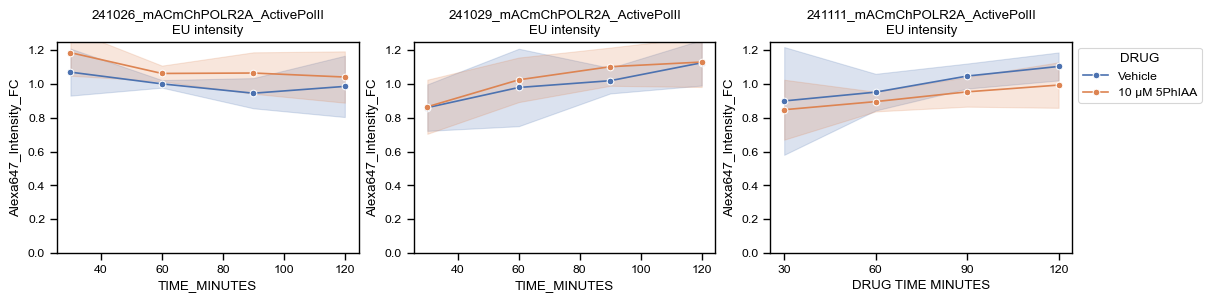

In [71]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, nrows = 1, figsize = (12,5), layout = 'constrained')

EU_IntensitiesByWell_Experiment1_Plot = EU_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
EU_IntensitiesByWell_Experiment1_Plot['TIME_MINUTES'] = EU_IntensitiesByWell_Experiment1_Plot['DRUG TIME MINUTES'].astype('int')

EU_IntensitiesByWell_Experiment2_Plot = EU_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
EU_IntensitiesByWell_Experiment2_Plot['TIME_MINUTES'] = EU_IntensitiesByWell_Experiment2_Plot['DRUG TIME MINUTES'].astype('int')

EU_IntensitiesByWell_Experiment3_Plot = EU_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
EU_IntensitiesByWell_Experiment3_Plot['TIME_MINUTES'] = EU_IntensitiesByWell_Experiment3_Plot['DRUG TIME MINUTES'].astype('int')

h = sns.lineplot(
    EU_IntensitiesByWell_Experiment1_Plot,
    x = 'TIME_MINUTES',
    y = 'Alexa647_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[0],
    legend = False
)

h = sns.lineplot(
    EU_IntensitiesByWell_Experiment2_Plot,
    x = 'TIME_MINUTES',
    y = 'Alexa647_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[1],
    legend = False
)


h = sns.lineplot(
    EU_IntensitiesByWell_Experiment3_Plot,
    x = 'DRUG TIME MINUTES',
    y = 'Alexa647_Intensity_FC',
    hue = 'DRUG', hue_order = ['Vehicle', '10 µM 5PhIAA'],
    palette = 'deep',
    marker = 'o',
    errorbar = 'sd',
    ax = a[2]
)

sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))


for i in range(3):
    a[i].set_ylim(0,1.25)
    a[i].set_box_aspect(0.7)

a[0].set_title('241026_mACmChPOLR2A_ActivePolII\nEU intensity')
a[1].set_title('241029_mACmChPOLR2A_ActivePolII\nEU intensity')
a[2].set_title('241111_mACmChPOLR2A_ActivePolII\nEU intensity')

In [72]:
EU_IntensitiesByWell = pd.concat([EU_IntensitiesByWell_Experiment1, EU_IntensitiesByWell_Experiment2, EU_IntensitiesByWell_Experiment3])

## fold vehicle treatments in 0 timepoint

In [73]:
IntensitiesByWell.DRUG.unique()

array(['No addition', '10 µM 5PhIAA', 'Vehicle'], dtype=object)

In [74]:
def time_in_aux(d,t):
    if d == "Vehicle":
        return 0
    elif d == "No addition":
        return 0
    elif d == "10 µM 5PhIAA":
        return t

In [75]:
IntensitiesByWell['TIME_IN_AUXIN'] = IntensitiesByWell.apply(lambda x: time_in_aux(x['DRUG'], x['DRUG TIME MINUTES']), axis = 1)
IntensitiesByWell['TIME_IN_AUXIN'] = IntensitiesByWell['TIME_IN_AUXIN'].astype('int')
IntensitiesByWell['TIME_IN_AUXIN_HRS'] = IntensitiesByWell['TIME_IN_AUXIN'] / 60

Total_IntensitiesByWell['TIME_IN_AUXIN'] = Total_IntensitiesByWell.apply(lambda x: time_in_aux(x['DRUG'], x['DRUG TIME MINUTES']), axis = 1)
Total_IntensitiesByWell['TIME_IN_AUXIN'] = Total_IntensitiesByWell['TIME_IN_AUXIN'].astype('int')
Total_IntensitiesByWell['TIME_IN_AUXIN_HRS'] = Total_IntensitiesByWell['TIME_IN_AUXIN'] / 60

pSer2_IntensitiesByWell['TIME_IN_AUXIN'] = pSer2_IntensitiesByWell.apply(lambda x: time_in_aux(x['DRUG'], x['DRUG TIME MINUTES']), axis = 1)
pSer2_IntensitiesByWell['TIME_IN_AUXIN'] = pSer2_IntensitiesByWell['TIME_IN_AUXIN'].astype('int')
pSer2_IntensitiesByWell['TIME_IN_AUXIN_HRS'] = pSer2_IntensitiesByWell['TIME_IN_AUXIN'] / 60

EU_IntensitiesByWell['TIME_IN_AUXIN'] = EU_IntensitiesByWell.apply(lambda x: time_in_aux(x['DRUG'], x['DRUG TIME MINUTES']), axis = 1)
EU_IntensitiesByWell['TIME_IN_AUXIN'] = EU_IntensitiesByWell['TIME_IN_AUXIN'].astype('int')
EU_IntensitiesByWell['TIME_IN_AUXIN_HRS'] = EU_IntensitiesByWell['TIME_IN_AUXIN'] / 60

# publication plots

## normalised GFP, RFP, total Pol II, and pSer2 Pol II plots

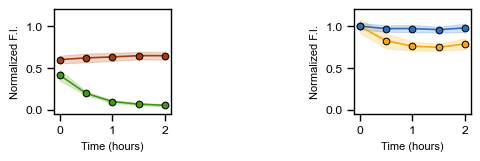

In [76]:
sns.set_context('paper')

mACmCherry_Plot = IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
mACmCherry_Total_Plot = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
mACmCherry_pSer2_Plot = pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')

f, a = plt.subplots(ncols = 2, figsize = (6,1.5), layout = 'constrained')

sns.lineplot(mACmCherry_Plot, 
             x = 'TIME_IN_AUXIN_HRS', 
             y = 'GFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'xkcd:grass green', 
             legend = False)

sns.lineplot(mACmCherry_Plot, 
             x = 'TIME_IN_AUXIN_HRS', 
             y = 'RFP_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'xkcd:rust', 
             legend = False)

sns.lineplot(mACmCherry_Total_Plot, 
             x = 'TIME_IN_AUXIN_HRS', 
             y = 'Alexa647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[1], 
             color = 'orange', 
             legend = False)

sns.lineplot(mACmCherry_pSer2_Plot, 
             x = 'TIME_IN_AUXIN_HRS', 
             y = 'Alexa647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[1], 
             color = 'xkcd:medium blue', 
             legend = False)

for i in range(2):
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].set_ylim(-0.05,1.2)
    a[i].set_yticks([0,0.5,1])
    a[i].set_xticks([0, 1, 2])
    a[i].set_xlim(-0.1,2.1)


plt.savefig('mACmCherryPOLR2A_GFP_RFP_Total_pSer2.svg')

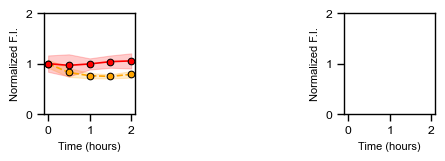

In [77]:
sns.set_context('paper')


mACmCherry_Total_Plot = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')
mACmCherry_EU_Plot = EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"')

f, a = plt.subplots(ncols = 2, figsize = (6,1.5), layout = 'constrained')

sns.lineplot(mACmCherry_Total_Plot, 
             x = 'TIME_IN_AUXIN_HRS', 
             y = 'Alexa647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'orange', 
             linestyle = '--',
             legend = False)

sns.lineplot(mACmCherry_EU_Plot, 
             x = 'TIME_IN_AUXIN_HRS', 
             y = 'Alexa647_Intensity_FC',
             marker = 'o', markeredgecolor = 'black',
             errorbar = 'sd',
             ax = a[0], 
             color = 'red',
             legend = False)

for i in range(2):
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(1.1)
    a[i].set_ylim(0,2)
    a[i].set_yticks([0,1,2])
    a[i].set_xticks([0, 1, 2])
    a[i].set_xlim(-0.1,2.1)

plt.savefig('mACmCherryPOLR2A_EU_total_dashed.svg')

## total pol II versus active pol II xy scatterplot

In [78]:
# pull means and standard deviation values for both total Pol II IF and pSer2 IF, vehicle treated

TotalVehicleMean = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"')['Alexa647_Intensity_FC'].mean()
TotalVehicleSD = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"')['Alexa647_Intensity_FC'].std()

pSer2VehicleMean = pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"')['Alexa647_Intensity_FC'].mean()
pSer2VehicleSD = pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"')['Alexa647_Intensity_FC'].std()

EUVehicleMean = EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"')['Alexa647_Intensity_FC'].mean()
EUVehicleSD = EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle"')['Alexa647_Intensity_FC'].std()

In [79]:
# pull means and standard deviation values for both total Pol II IF and pSer2 IF, grouped by timepoint

TotalGroupedMean = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "10 µM 5PhIAA"')[['DRUG TIME MINUTES','Alexa647_Intensity_FC']].groupby(['DRUG TIME MINUTES']).mean().reset_index()
TotalGroupedSD = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "10 µM 5PhIAA"')[['DRUG TIME MINUTES','Alexa647_Intensity_FC']].groupby(['DRUG TIME MINUTES']).std().reset_index()

pSer2GroupedMean = pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "10 µM 5PhIAA"')[['DRUG TIME MINUTES','Alexa647_Intensity_FC']].groupby(['DRUG TIME MINUTES']).mean().reset_index()
pSer2GroupedSD = pSer2_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "10 µM 5PhIAA"')[['DRUG TIME MINUTES','Alexa647_Intensity_FC']].groupby(['DRUG TIME MINUTES']).std().reset_index()

EUGroupedMean = EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "10 µM 5PhIAA"')[['DRUG TIME MINUTES','Alexa647_Intensity_FC']].groupby(['DRUG TIME MINUTES']).mean().reset_index()
EUGroupedSD = EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "10 µM 5PhIAA"')[['DRUG TIME MINUTES','Alexa647_Intensity_FC']].groupby(['DRUG TIME MINUTES']).std().reset_index()

In [80]:
TotalGroupedMean.rename(columns = {'Alexa647_Intensity_FC' : 'TotalPolII'}, inplace = True)
TotalGroupedSD.rename(columns = {'Alexa647_Intensity_FC' : 'TotalPolII_SD'}, inplace = True)
pSer2GroupedMean.rename(columns = {'Alexa647_Intensity_FC' : 'pSer2PolII'}, inplace = True)
pSer2GroupedSD.rename(columns = {'Alexa647_Intensity_FC' : 'pSer2PolII_SD'}, inplace = True)
EUGroupedMean.rename(columns = {'Alexa647_Intensity_FC' : 'EU'}, inplace = True)
EUGroupedSD.rename(columns = {'Alexa647_Intensity_FC' : 'EU_SD'}, inplace = True)

In [81]:
XYPLOT = TotalGroupedMean.merge(TotalGroupedSD).merge(pSer2GroupedMean).merge(pSer2GroupedSD)

In [82]:
XYPLOT

,DRUG TIME MINUTES,TotalPolII,TotalPolII_SD,pSer2PolII,pSer2PolII_SD
0,120,0.787130,0.065900,0.978936,0.051333
1,30,0.824509,0.088647,0.969679,0.037829
2,60,0.759984,0.053194,0.970598,0.044010
3,90,0.745999,0.040800,0.956705,0.034815


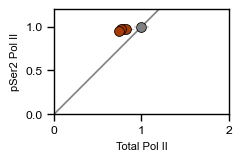

In [83]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (5,1.5), layout = 'constrained')

# plot error bars for vehicle treated point

plt.errorbar(x = [TotalVehicleMean], 
             xerr = [TotalVehicleSD],
             y = [pSer2VehicleMean], 
             yerr = [pSer2VehicleSD],
             color = 'grey',
             alpha = 0.4)

# plot error bars for 5-ph-iaa treated points

plt.errorbar(x = XYPLOT.TotalPolII,
             xerr = XYPLOT.TotalPolII_SD,
             y = XYPLOT.pSer2PolII,
             yerr = XYPLOT.pSer2PolII_SD,
             linestyle = "None", linewidth = 1,
             color = 'grey', 
             alpha = 0.4, zorder = 1)

# plot vehicle treated point in grey

sns.scatterplot(x = [TotalVehicleMean], y = [pSer2VehicleMean], color = 'grey', s = 50, edgecolor = 'black')

# plot total and pSer2 at each time and concentration

h = sns.scatterplot(XYPLOT,
                x = 'TotalPolII',
                y = 'pSer2PolII',

                color = 'xkcd:rust',
                marker = 'o', s = 50, edgecolor = 'black')

a.set_box_aspect(0.6)
a.set_ylim(0,1.2)
a.set_xlim(0,2)
a.set_xticks([0,1.0,2.0])
a.set_yticks([0,0.5,1,])

a.axline(xy1 = (0,0), slope = 1, color = 'grey', zorder = 0)

a.set_xlabel('Total Pol II', fontsize = 8)

a.set_ylabel('pSer2 Pol II', fontsize = 8)

plt.savefig('total_polii_vs_pser2_polii_mACmCherryPOLR2A_ActivePolII.svg')

In [84]:
XYPLOT_EU = TotalGroupedMean.merge(TotalGroupedSD).merge(EUGroupedMean).merge(EUGroupedSD)

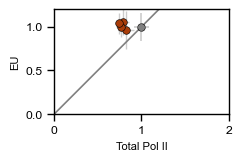

In [85]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (5,1.5), layout = 'constrained')

# plot error bars for vehicle treated point

plt.errorbar(x = [TotalVehicleMean], 
             xerr = [TotalVehicleSD],
             y = [EUVehicleMean], 
             yerr = [EUVehicleSD],
             color = 'grey',
             alpha = 0.4)

# plot error bars for 5-ph-iaa treated points

plt.errorbar(x = XYPLOT_EU.TotalPolII,
             xerr = XYPLOT_EU.TotalPolII_SD,
             y = XYPLOT_EU.EU,
             yerr = XYPLOT_EU.EU_SD,
             linestyle = "None", linewidth = 1,
             color = 'grey', 
             alpha = 0.4, zorder = 1)

# plot vehicle treated point in grey

sns.scatterplot(x = [TotalVehicleMean], y = [EUVehicleMean], color = 'grey', s = 30, edgecolor = 'black')

# plot total and pSer2 at each time and concentration

h = sns.scatterplot(XYPLOT_EU,
                x = 'TotalPolII',
                y = 'EU',

                color = 'xkcd:rust',
                marker = 'o', s = 30, edgecolor = 'black')

a.set_box_aspect(0.6)
a.set_ylim(0,1.2)
a.set_xlim(0,2)
a.set_xticks([0,1.0,2.0])
a.set_yticks([0,0.5,1,])

a.axline(xy1 = (0,0), slope = 1, color = 'grey', zorder = 0)

a.set_xlabel('Total Pol II', fontsize = 8)

a.set_ylabel('EU', fontsize = 8)

plt.savefig('eu_vs_pser2_polii_mACmCherryPOLR2A_ActivePolII.svg')

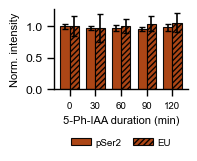

In [86]:
cell = "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1"

def build_assay_summary(df, assay_name, intensity_col):
    # Vehicle
    vehicle = df.query('CELL == @cell & DRUG == "Vehicle"')[intensity_col]
    rows = [{
        "Condition": "0",
        "Assay": assay_name,
        "Mean": vehicle.mean(),
        "SD": vehicle.std()
    }]

    # 5PhIAA time course
    grouped = (
        df.query('CELL == @cell & DRUG == "10 µM 5PhIAA"')[["DRUG TIME MINUTES", intensity_col]]
          .groupby("DRUG TIME MINUTES")
          .agg(Mean=(intensity_col, "mean"), SD=(intensity_col, "std"))
          .reset_index()
    )

    for _, r in grouped.iterrows():
        rows.append({
            "Condition": f'{r["DRUG TIME MINUTES"]}',
            "Assay": assay_name,
            "Mean": r["Mean"],
            "SD": r["SD"]
        })

    return pd.DataFrame(rows)

# Build summaries
pser2_summary = build_assay_summary(pSer2_IntensitiesByWell, "pSer2", "Alexa647_Intensity_FC")
eu_summary    = build_assay_summary(EU_IntensitiesByWell,    "EU",    "Alexa647_Intensity_FC")

plot_df = pd.concat([pser2_summary, eu_summary], ignore_index=True)

# Order: Vehicle first, then numeric timepoints
condition_order = ["0"] + sorted(
    [c for c in plot_df["Condition"].unique() if c != "0"],
    key=lambda s: float(s.split()[0])
)

plot_df["Condition"] = pd.Categorical(plot_df["Condition"], categories=condition_order, ordered=True)

sns.set_context("paper")

f, a = plt.subplots(figsize=(3.5, 1.5), layout="constrained")

x = np.arange(len(condition_order))
width = 0.36

assay_styles = {
    "pSer2": {"color": "xkcd:rust", "hatch": ""},
    "EU":    {"color": "xkcd:rust", "hatch": "//////"},
}

for i, assay in enumerate(["pSer2", "EU"]):
    sub = (
        plot_df.loc[plot_df["Assay"] == assay]
        .set_index("Condition")
        .reindex(condition_order)
    )

    xpos = x + (i - 0.5) * width

    a.bar(
        xpos,
        sub["Mean"],
        width=width,
        yerr=sub["SD"],
        capsize=2,
        color=assay_styles[assay]["color"],
        edgecolor="black",
        linewidth=0.8,
        hatch=assay_styles[assay]["hatch"],
        alpha=0.95,
        label=assay,
    )

a.set_xticks(x)
a.set_xticklabels(condition_order, fontsize=7)
a.set_xlabel("5-Ph-IAA duration (min)", fontsize=8)
a.set_ylabel("Norm. intensity", fontsize=8)
a.set_box_aspect(0.6)

a.legend(
    frameon=False,
    fontsize=7,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.5),
    ncol=2,
    columnspacing=1.2,
    handletextpad=0.5
)
sns.despine(ax=a)

plt.savefig("pser2_vs_EU_barplot_mACmCh_POLR2A.svg", bbox_inches="tight")
plt.savefig("pser2_vs_EU_barplot_mACmCh_POLR2A.pdf", bbox_inches="tight")